# **German Housing Market — Showcase EDA**

Exploratory analysis of two open datasets covering the German residential 
property market. This notebook demonstrates the datasets in action with 
key visualisations across price trends, affordability, credit conditions, 
and housing supply.

**Datasets:**
- [German City-Level Housing Market Dataset (2005–2024)](https://www.kaggle.com/datasets/meenaaditya/german-city-housing-market-dataset)
- [Germany Macroeconomic Housing Indicators (2005–2025)](https://www.kaggle.com/datasets/meenaaditya/germany-macroeconomic-housing-indicators)

**Author:** Aditya Meena — M.Sc. Data Analytics, Universität Hildesheim

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

In [7]:
# Creating figures/plots folder

import os
os.makedirs("figures", exist_ok=True)

In [2]:
# Plot styling

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 150
plt.rcParams["font.family"] = "sans-serif"

In [3]:
# Loading datasets

city = pd.read_csv("data_clean/city_master_dataset.csv", parse_dates=["date"])
macro = pd.read_csv("data_clean/macro_master_dataset.csv")

print("City dataset:", city.shape)
print("Macro dataset:", macro.shape)

City dataset: (30019, 11)
Macro dataset: (21, 21)


In [4]:
# Quick overview

print("City Dataset")
print(f"Cities: {sorted(city["city"].unique())}")
print(f"Property types: {list(city["property_type"].unique())}")
print(f"Date range: {city["date"].min().date()} to {city["date"].max().date()}")
print(f"Rows: {len(city):,}")

print()
print("Macro Dataset")
print(f"Year range: {macro["year"].min()} to {macro["year"].max()}")
print(f"Rows: {len(macro)}")
print(f"Indicators: {len(macro.columns) - 1}")

City Dataset
Cities: ['Bochum', 'Bonn', 'Chemnitz', 'Dortmund', 'Dresden', 'Duisburg', 'Düsseldorf', 'Erfurt', 'Frankfurt am Main', 'Hamburg', 'Karlsruhe', 'Kreis Mettmann', 'Köln', 'Leipzig', 'Lübeck', 'München', 'Münster', 'Potsdam', 'Rhein-Erft-Kreis', 'Stuttgart', 'Wiesbaden']
Property types: ['single_family', 'apartment', 'multi_family']
Date range: 2005-01-01 to 2024-10-01
Rows: 30,019

Macro Dataset
Year range: 2005 to 2025
Rows: 21
Indicators: 20


# Apartment Price Trends Across Major Cities (2005-2024)

Quarterly apartment transaction prices across selected major German cities. Highlights the 2015-2022 price boom and the subsequent correction.

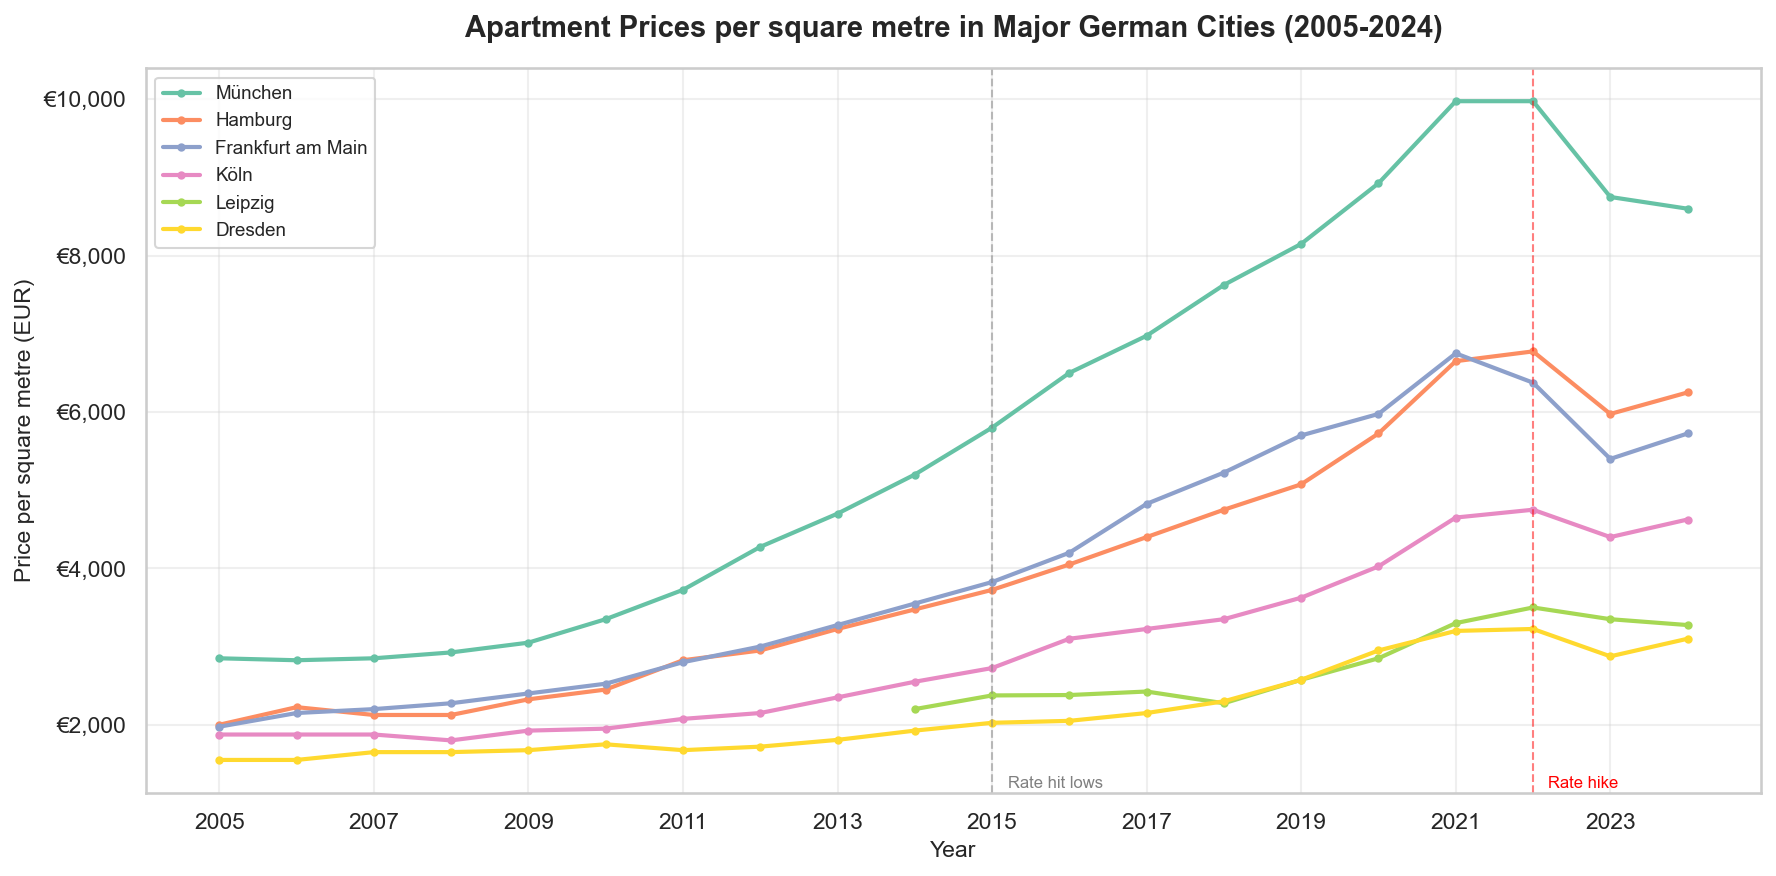

Plot 1 saved.


In [9]:
# Select major cities for clarity

major_cities = ["München", "Hamburg", "Frankfurt am Main",
                "Berlin" if "Berlin" in city["city"].unique() else "Köln",
                "Leipzig", "Dresden"]

# Use cities that actually exist in the dataset

major_cities = [c for c in major_cities if c in city["city"].unique()]

# Aggregate to annual average price per city for apartments

city_apts = city[(city["property_type"] == "apartment") & (city["city"].isin(major_cities))].copy()

# Annual average 

city_annual = city_apts.groupby(["year", "city"])["price_m2"].mean().reset_index()

# Plot

fig, ax = plt.subplots(figsize=(12,6))
colors = plt.cm.Set2.colors 
for i, c in enumerate(major_cities):
    data = city_annual[city_annual["city"] == c]
    ax.plot(data["year"], data["price_m2"], marker="o", markersize=3, linewidth=2, label=c, color=colors[i])

# Annotations

ax.axvline(x=2015, color="gray", linestyle="--", alpha=0.5, linewidth=1)
ax.axvline(x=2022, color="red", linestyle="--", alpha=0.5, linewidth=1)
ax.text(2015.2, ax.get_ylim()[0] * 1.05, "Rate hit lows", fontsize=8, color="gray")
ax.text(2022.2, ax.get_ylim()[0] * 1.05, "Rate hike", fontsize=8, color="red")

ax.set_title("Apartment Prices per square metre in Major German Cities (2005-2024)", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Price per square metre (EUR)", fontsize=11)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"€{x:,.0f}"))
ax.set_xticks(range(2005, 2025, 2))
ax.set_xticklabels(range(2005, 2025, 2))
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figures/plot1_city_price_trends.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot 1 saved.")

# Mortgage Rates vs National House Price Index (2005-2024)

Dual-axis chart overlaying average mortgage rates against the national house price index. Demonstrates the inverse relationship between financing costs and property prices which is the core diagnostic finding.

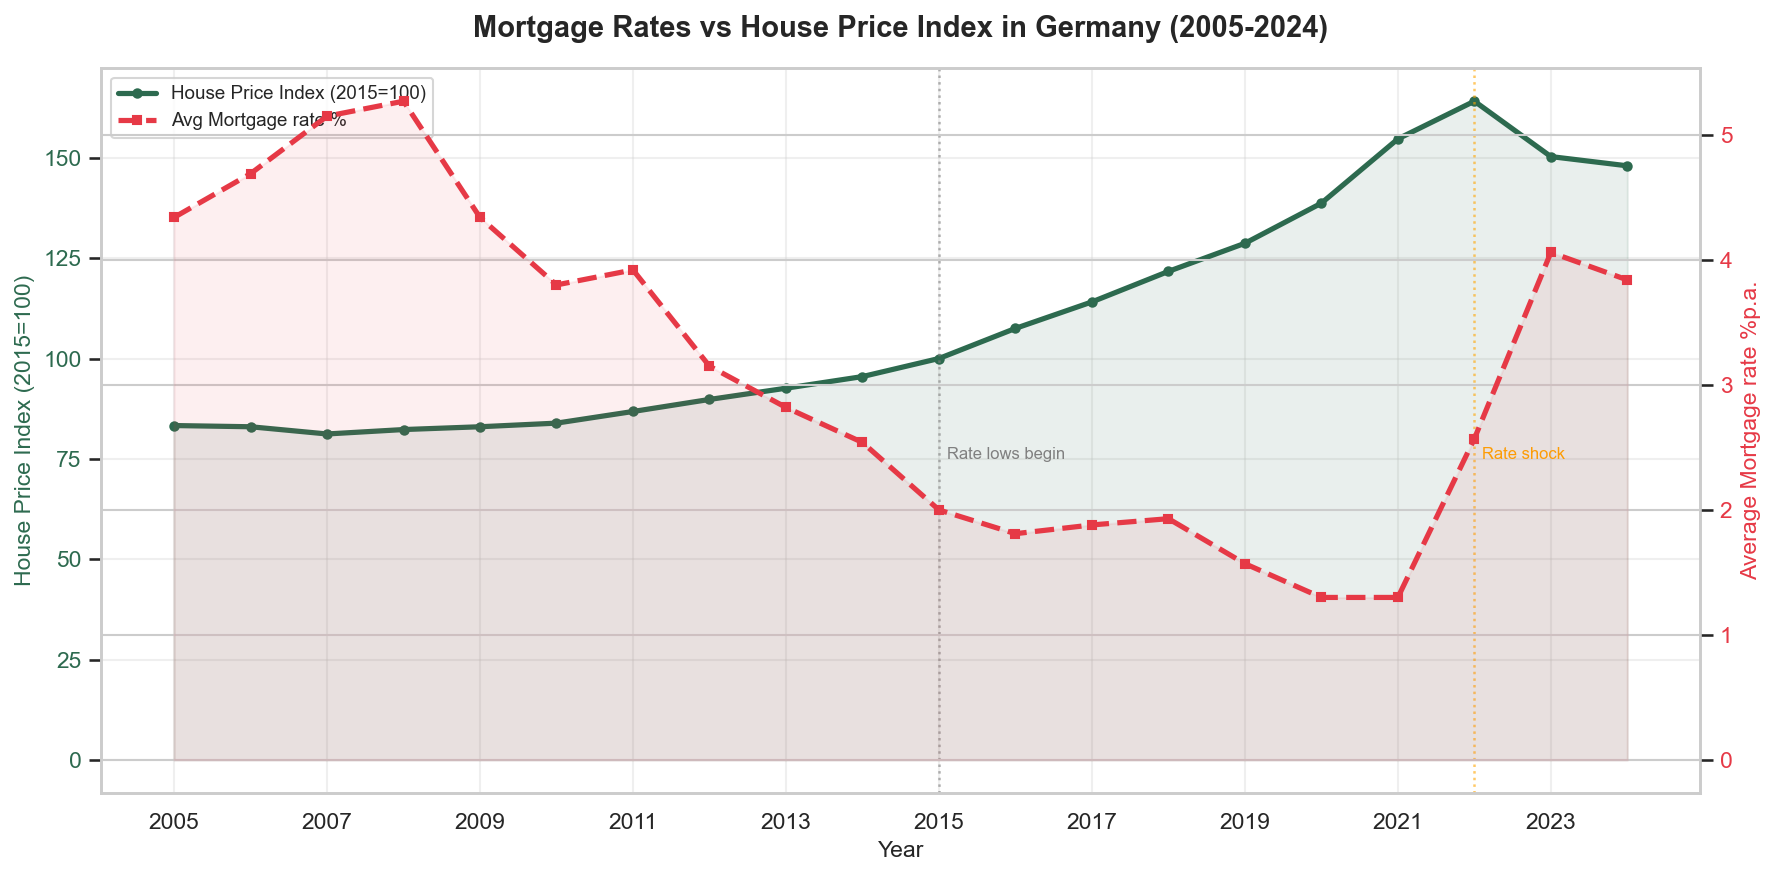

Plot 2 saved.


In [11]:
# Filter macro to 2005-2024 since HPI is only available till 2024

macro_plot = macro[macro["year"].between(2005, 2024)].copy()
fig, ax1 = plt.subplots(figsize=(12,6))

# Left axis: HPI

color_hpi = "#2D6A4F"
ax1.plot(macro_plot["year"], macro_plot["hpi_overall"], color=color_hpi, linewidth=2.5, marker="o", markersize=4, label="House Price Index (2015=100)")
ax1.fill_between(macro_plot["year"], macro_plot["hpi_overall"], alpha=0.1, color=color_hpi)
ax1.set_xlabel("Year", fontsize=11)
ax1.set_ylabel("House Price Index (2015=100)", fontsize=11, color=color_hpi)
ax1.tick_params(axis="y", labelcolor=color_hpi)
ax1.set_xticks(range(2005, 2025, 2))

# Right axis: Mortgage rate

ax2 = ax1.twinx()
color_rate = "#E63946"
ax2.plot(macro_plot["year"], macro_plot["mortgage_rate_avg_pct"], color=color_rate, linewidth=2.5, marker="s", markersize=4, linestyle="--", label="Avg Mortgage rate %")
ax2.fill_between(macro_plot["year"], macro_plot["mortgage_rate_avg_pct"], alpha=0.08, color=color_rate)
ax2.set_ylabel("Average Mortgage rate %p.a.", fontsize=11, color=color_rate)
ax2.tick_params(axis="y", labelcolor=color_rate)

# Annotations

ax1.axvline(x=2015, color="gray", linestyle=":", alpha=0.6, linewidth=1.2)
ax1.axvline(x=2022, color="orange", linestyle=":", alpha=0.6, linewidth=1.2)
ax1.text(2015.1, 75, "Rate lows begin", fontsize=8, color="gray")
ax1.text(2022.1, 75, "Rate shock", fontsize=8, color="orange")

# Combined legend

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

ax1.set_title("Mortgage Rates vs House Price Index in Germany (2005-2024)", fontsize=14, fontweight="bold", pad=15)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figures/plot2_mortgage_vs_hpi.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot 2 saved.")

# Housing Affordability Heatmap Across Cities (2005-2024)

Affordability ratio (mortgage cost as share of income) per city per year. Higher values indicate greater affordability stress, more income required to service a mortgage. Reveals which cities become unaffordable and when. 

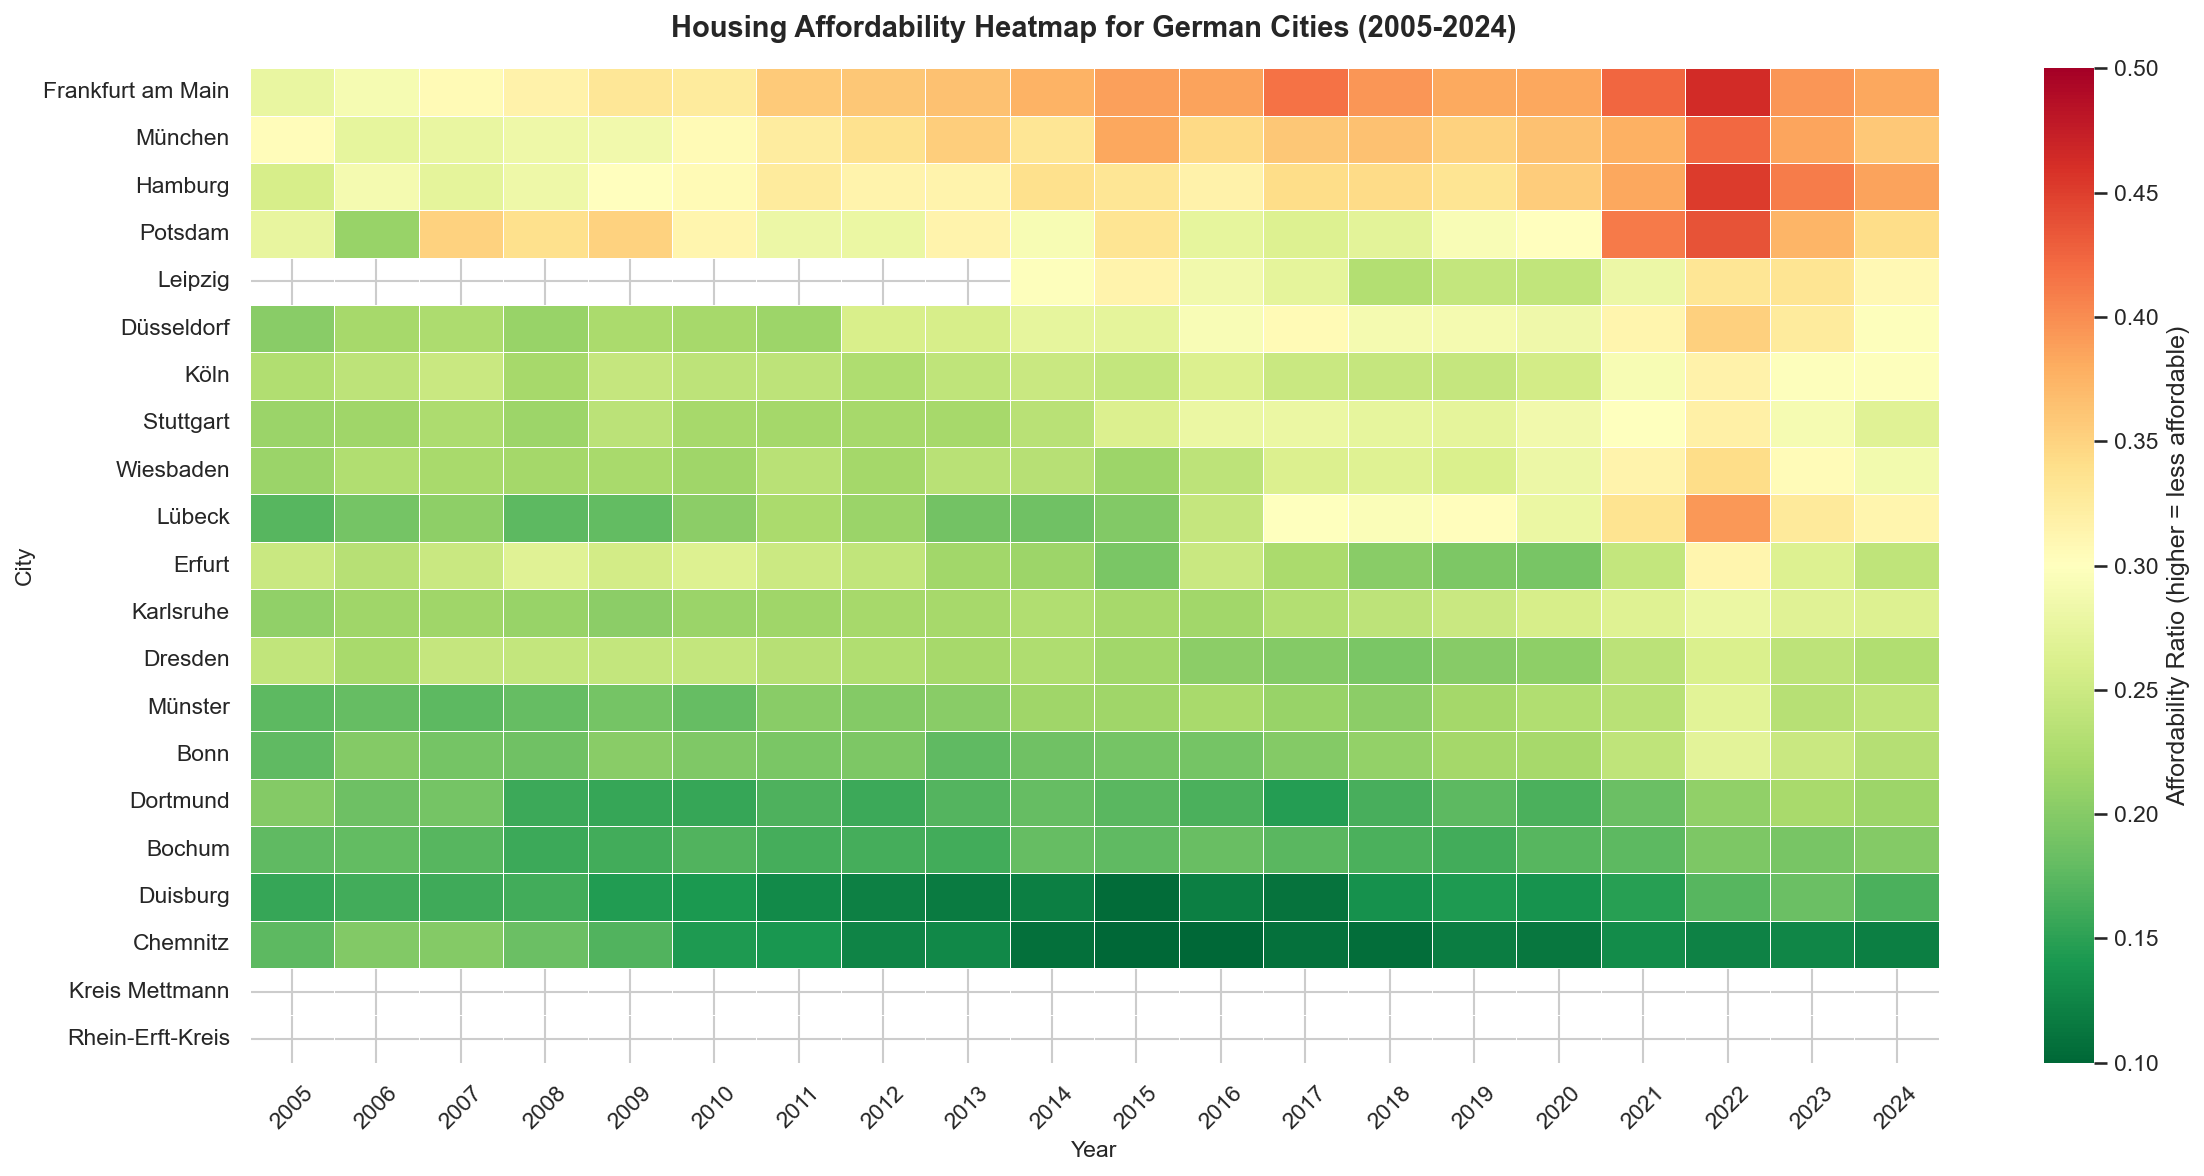

Plot 3 saved.


In [13]:
# Pivot affordability data

affordability_pivot = city.groupby(["city", "year"])["affordability_ratio"].mean().reset_index()
affordability_pivot = affordability_pivot.pivot(index="city", columns="year", values="affordability_ratio")

# Drop years with too many NaN values

affordability_pivot = affordability_pivot.dropna(thresh=10, axis=1)

# Sort cities by mean affordability

affordability_pivot = affordability_pivot.loc[affordability_pivot.mean(axis=1).sort_values(ascending=False).index]

# Plot

fig, ax = plt.subplots(figsize=(16,8))
sns.heatmap(affordability_pivot, cmap="RdYlGn_r", annot=False, linewidth=0.3, linecolor="white", ax=ax,
            cbar_kws={"label": "Affordability Ratio (higher = less affordable)"}, vmin=0.1, vmax=0.5)

ax.set_title("Housing Affordability Heatmap for German Cities (2005-2024)", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("City", fontsize=11)
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig("figures/plot3_affordability_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot 3 saved.")

# Residential Building Permits Collapse (2005-2025)

Annual residential building permits issued in Germany. Highlights the dramatic supply-side contraction post-2022 driven by rising construction costs and financing rates, a key factor preventing prices from correcting further despite demand failing.

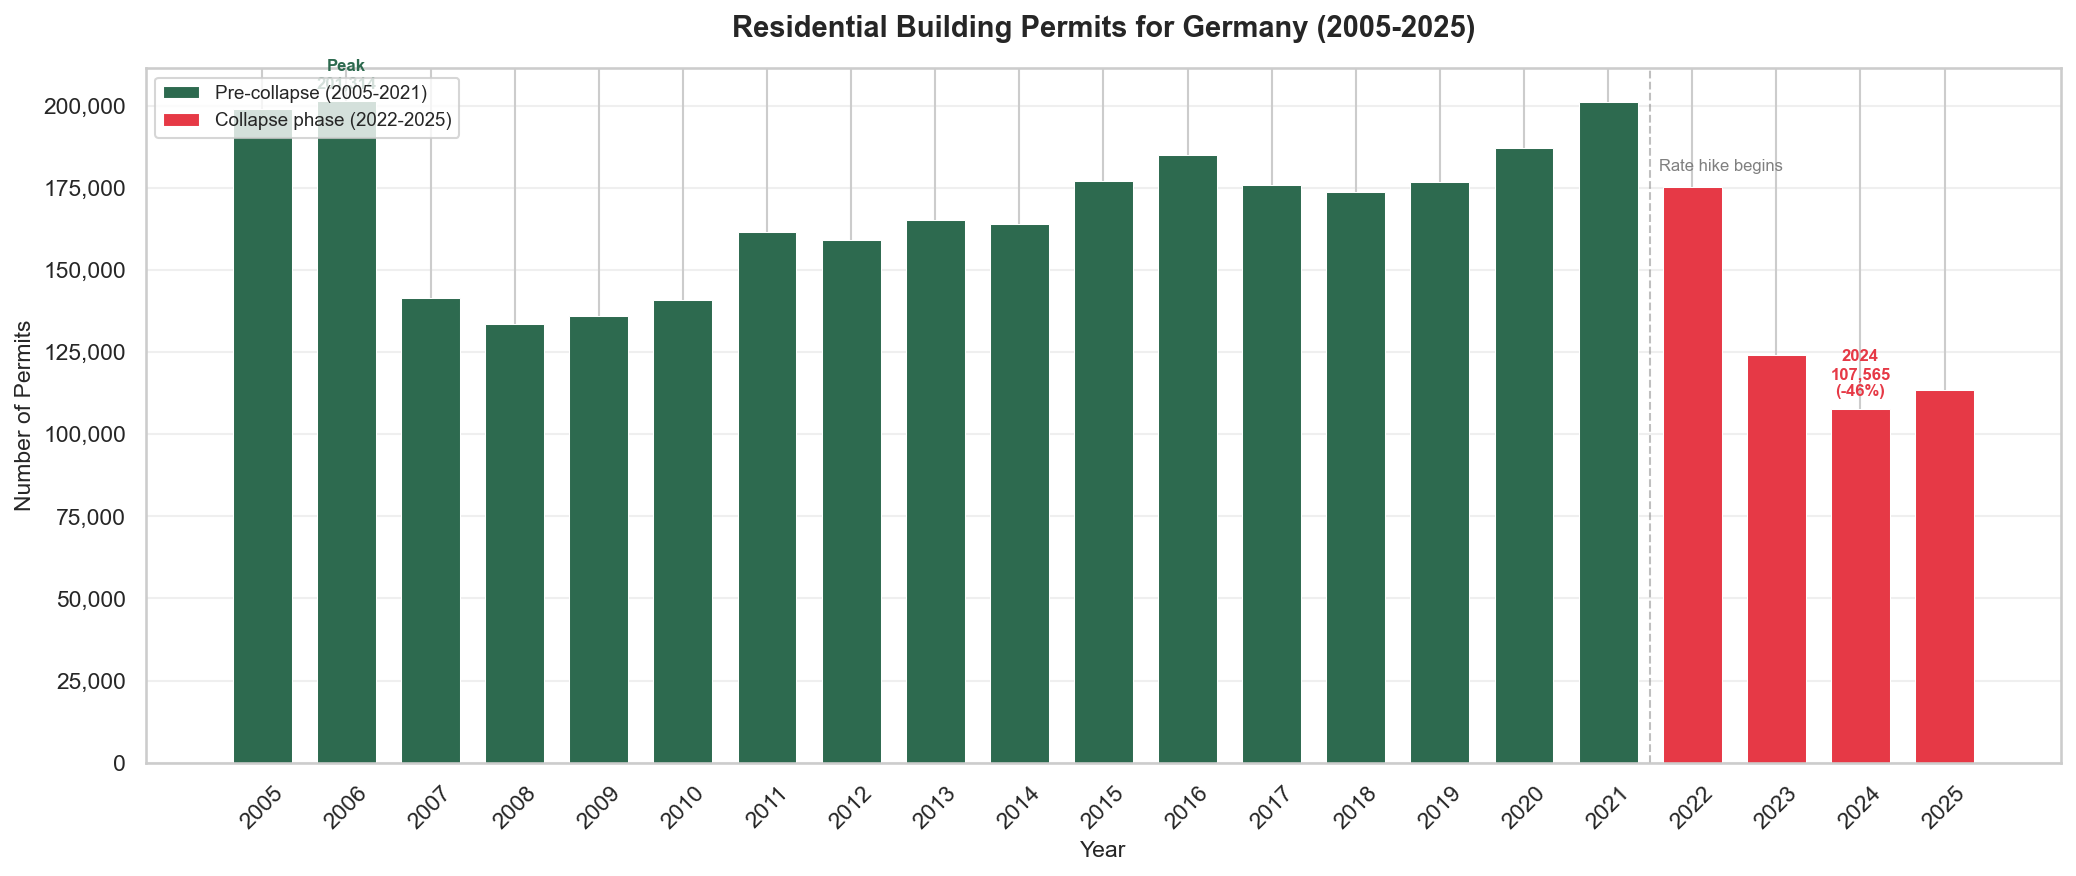

Plot 4 saved.


In [21]:
# Filter macro for permits

permits_plot = macro[macro["year"].between(2005, 2025)].copy()

# Color bars

colors = ["#2D6A4F" if y <= 2021 else "#E63946" for y in permits_plot["year"]]

fig, ax = plt.subplots(figsize=(14,6))
bars = ax.bar(permits_plot["year"], permits_plot["building_permits_residential"], color=colors, edgecolor="white", linewidth=0.5, width=0.7)

# Peak Annotation

peak_idx = permits_plot["building_permits_residential"].idxmax()
peak_year = int(permits_plot.loc[peak_idx, "year"])
peak_val = int(permits_plot.loc[peak_idx, "building_permits_residential"])
ax.text(peak_year, peak_val + 4000, f"Peak\n{peak_val:,.0f}", ha="center", fontsize=8, color="#2D6A4F", fontweight="bold")

# 2024 Annotation

val_2024 = int(permits_plot.loc[permits_plot["year"] == 2024, "building_permits_residential"].values[0])
ax.text(2024, val_2024 + 4000, f"2024\n{val_2024:,.0f}\n(-46%)", ha="center", fontsize=8, color="#E63946", fontweight="bold")

# Reference line at 2021

ax.axvline(x=2021.5, color="gray", linestyle="--", alpha=0.5, linewidth=1)
ax.text(2021.6, 180000, "Rate hike begins", fontsize=8, color="gray")

ax.set_title("Residential Building Permits for Germany (2005-2025)", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Number of Permits", fontsize=11)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_xticks(permits_plot["year"])
ax.tick_params(axis="x", rotation=45)

# Legend

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#2D6A4F", label="Pre-collapse (2005-2021)"),
                   Patch(facecolor="#E63946", label="Collapse phase (2022-2025)")]
ax.legend(handles=legend_elements, fontsize=9, loc="upper left")

ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("figures/plot4_building_permits.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot 4 saved.")

# Key Findings

**1. Cheap money boom (2015-2022)** - As mortgage rates fell from 5%+ to a historic low of 1.2% by 2020-2021, apartment prices in major cities more than doubled. München peaked at nearly €10,000/msq., up from €3,000 in 2005.

**2.The 2022 rate shock** - The ECB rate hike cycle pushed average mortgage rates from 1.3% to 4.1% in just two year which is the sharpest rise in the dataset. Every major city shows a visible price correction immediately after.

**3. Supply collapse prevented deeper correction** - Residential building permits fell 46% from their 2006/2021 peak to 107,565 in 2024 which is the lowest in the dataset. Constrained supply absorbed some of the demand shock, preventing prices from falling further.

**4. East-West affordability divide** - The affordability heatmap reveals a persistent structural divide. Western cities (Frankfurt am Main, München, Hmaburg) became deeply unaffordable post-2015, while Eastern cities (Chemnitz, Duisburg, Dortmund) remained relatively accessible throughout the entire period.

**5. Frankfurt am Main, the most affordability-stressed city** - Despite not having the highest absolute prices, Frankfurt consistently shows the highest affordability ratio, meaning buyers there spend the largest share of income servicing a mortgage. 

*Analysis based on GREIX transaction data, Destatis, and Deutsche Bundesbank.*
*Datasets available on Kaggle*